In [4]:
import os 
print(os.getcwd())

C:\Users\Dell\Downloads\blinkit


In [8]:
import os
os.chdir(r'C:\Users\Dell\Downloads\blinkit')
print(os.listdir())

['blinkit_customers_cleaned.xlsx', 'blinkit_inventory_cleaned.xlsx', 'blinkit_orders_cleaned.xlsx', 'blinkit_order_items_cleaned.xlsx', 'blinkit_products_cleaned.xlsx']


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'C:\Users\Dell\Downloads\blinkit')

orders = pd.read_excel('blinkit_orders_cleaned.xlsx')
products = pd.read_excel('blinkit_products_cleaned.xlsx')
order_items = pd.read_excel('blinkit_order_items_cleaned.xlsx')
customers = pd.read_excel('blinkit_customers_cleaned.xlsx')
inventory = pd.read_excel('blinkit_inventory_cleaned.xlsx')

print("Orders:", orders.shape)
print("Products:", products.shape)
print("Order Items:", order_items.shape)
print("Customers:", customers.shape)
print("Inventory:", inventory.shape)

Orders: (5000, 12)
Products: (268, 11)
Order Items: (5000, 5)
Customers: (2500, 12)
Inventory: (75172, 5)


In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'C:\Users\Dell\Downloads\blinkit')

orders = pd.read_excel('blinkit_orders_cleaned.xlsx')
products = pd.read_excel('blinkit_products_cleaned.xlsx')
order_items = pd.read_excel('blinkit_order_items_cleaned.xlsx')
customers = pd.read_excel('blinkit_customers_cleaned.xlsx')
inventory = pd.read_excel('blinkit_inventory_cleaned.xlsx')

print("Orders:", orders.shape)
print("Products:", products.shape)
print("Order Items:", order_items.shape)
print("Customers:", customers.shape)
print("Inventory:", inventory.shape)

Orders: (5000, 12)
Products: (268, 11)
Order Items: (5000, 5)
Customers: (2500, 12)
Inventory: (75172, 5)


In [13]:
# Basic overview of orders table
print("=== ORDERS OVERVIEW ===")
print(orders.info())
print("\n=== BASIC STATISTICS ===")
print(orders.describe())

=== ORDERS OVERVIEW ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                5000 non-null   int64         
 1   customer_id             5000 non-null   int64         
 2   order_date              5000 non-null   datetime64[ns]
 3   promised_delivery_time  5000 non-null   datetime64[ns]
 4   actual_delivery_time    5000 non-null   datetime64[ns]
 5   delivery_status         5000 non-null   object        
 6   order_total             5000 non-null   float64       
 7   payment_method          5000 non-null   object        
 8   delivery_partner_id     5000 non-null   int64         
 9   store_id                5000 non-null   int64         
 10  Delivery Delay (mins)   5000 non-null   float64       
 11  Order Month             5000 non-null   object        
dtypes: datetime64[ns](3), fl

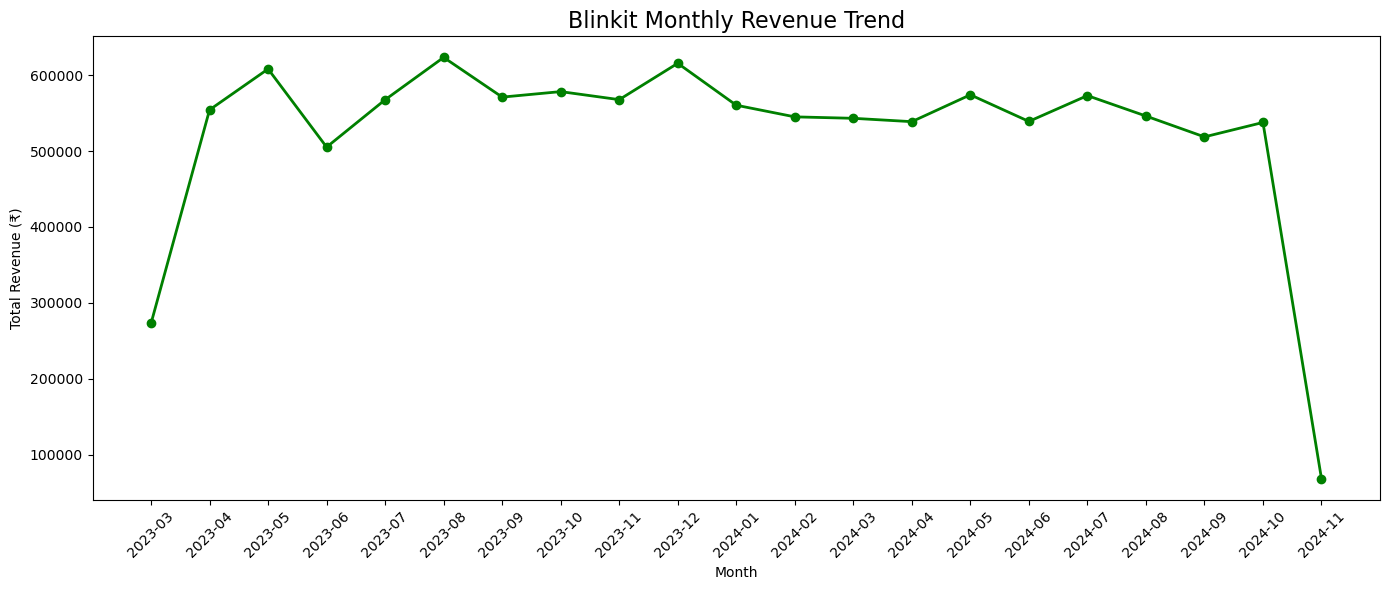

In [14]:
# Convert order_date to datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Extract month year
orders['order_month'] = orders['order_date'].dt.to_period('M')

# Group by month
monthly_revenue = orders.groupby('order_month')['order_total'].sum().reset_index()
monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)

# Plot
plt.figure(figsize=(14,6))
plt.plot(monthly_revenue['order_month'], 
         monthly_revenue['order_total'], 
         marker='o', color='green', linewidth=2)
plt.title('Blinkit Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

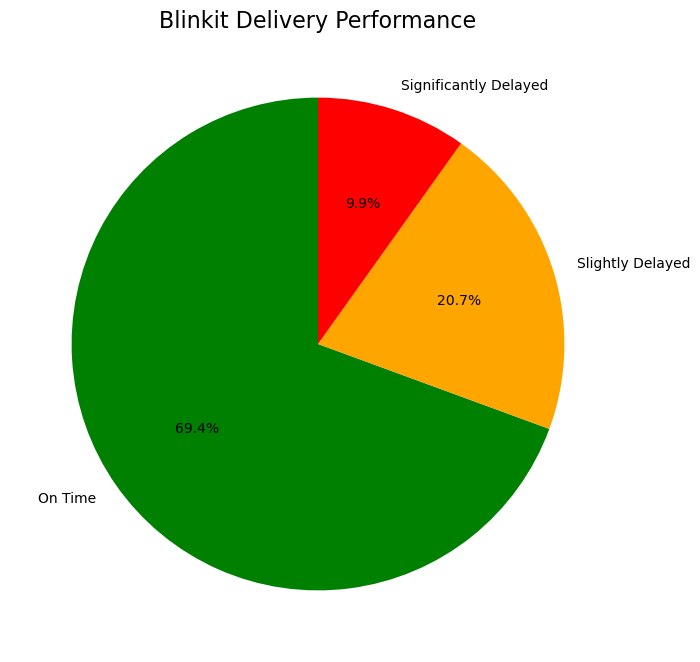

In [15]:
# Count delivery status
delivery_counts = orders['delivery_status'].value_counts()

# Plot
plt.figure(figsize=(8,8))
plt.pie(delivery_counts, 
        labels=delivery_counts.index,
        autopct='%1.1f%%',
        colors=['green','orange','red'],
        startangle=90)
plt.title('Blinkit Delivery Performance', fontsize=16)
plt.show()

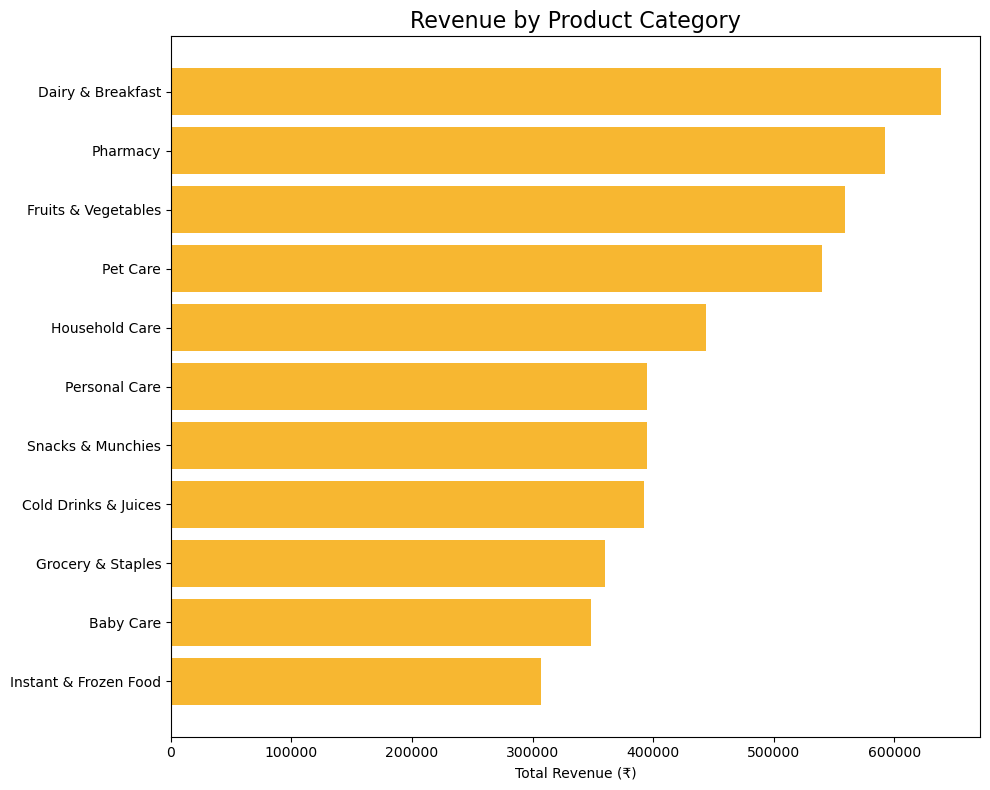

In [20]:
# Merge order_items with products
merged = order_items.merge(products, on='product_id')

# Revenue by category
category_revenue = merged.groupby('category')['Total item value'].sum().sort_values(ascending=True)

# Plot
plt.figure(figsize=(10,8))
plt.barh(category_revenue.index, 
         category_revenue.values,
         color='#f7b731')
plt.title('Revenue by Product Category', fontsize=16)
plt.xlabel('Total Revenue (₹)')
plt.tight_layout()
plt.show()

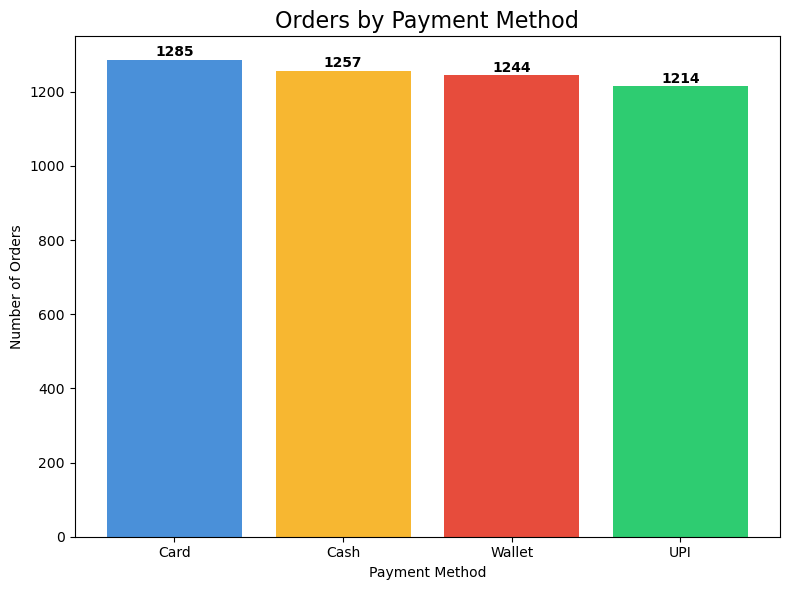

In [21]:
# Payment method counts
payment_counts = orders['payment_method'].value_counts()

# Plot
plt.figure(figsize=(8,6))
plt.bar(payment_counts.index, 
        payment_counts.values,
        color=['#4a90d9','#f7b731','#e74c3c','#2ecc71'])
plt.title('Orders by Payment Method', fontsize=16)
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
for i, v in enumerate(payment_counts.values):
    plt.text(i, v+10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

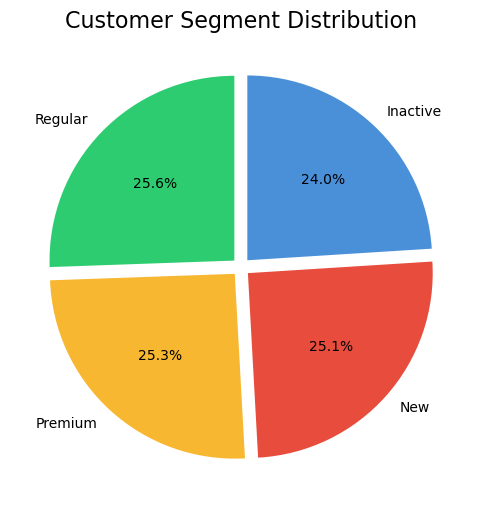

In [22]:
# Customer segment counts
segment_counts = customers['customer_segment'].value_counts()

# Plot
plt.figure(figsize=(8,6))
colors = ['#2ecc71','#f7b731','#e74c3c','#4a90d9']
plt.pie(segment_counts,
        labels=segment_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        explode=[0.05,0.05,0.05,0.05])
plt.title('Customer Segment Distribution', fontsize=16)
plt.show()

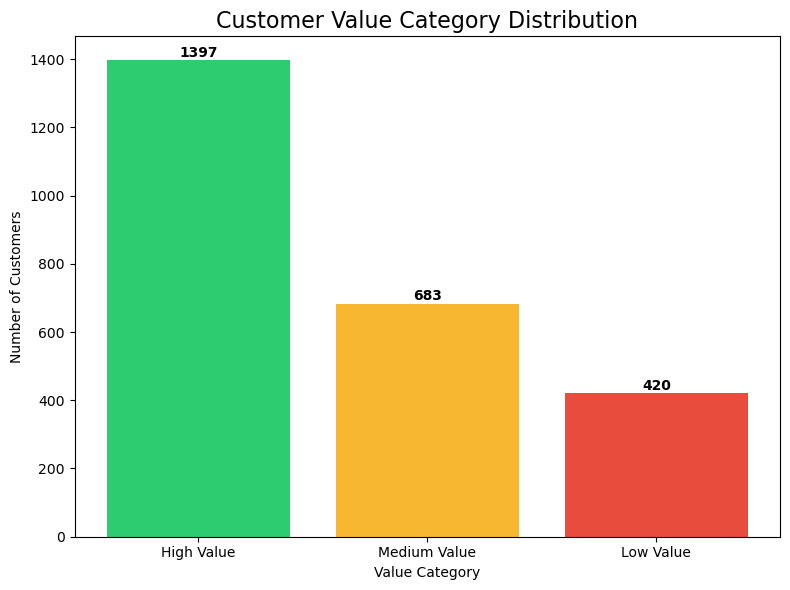

In [24]:
# Customer value category
value_counts = customers['Customer Value Category'].value_counts()

# Plot
plt.figure(figsize=(8,6))
plt.bar(value_counts.index,
        value_counts.values,
        color=['#2ecc71','#f7b731','#e74c3c'])
plt.title('Customer Value Category Distribution', fontsize=16)
plt.xlabel('Value Category')
plt.ylabel('Number of Customers')
for i, v in enumerate(value_counts.values):
    plt.text(i, v+10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

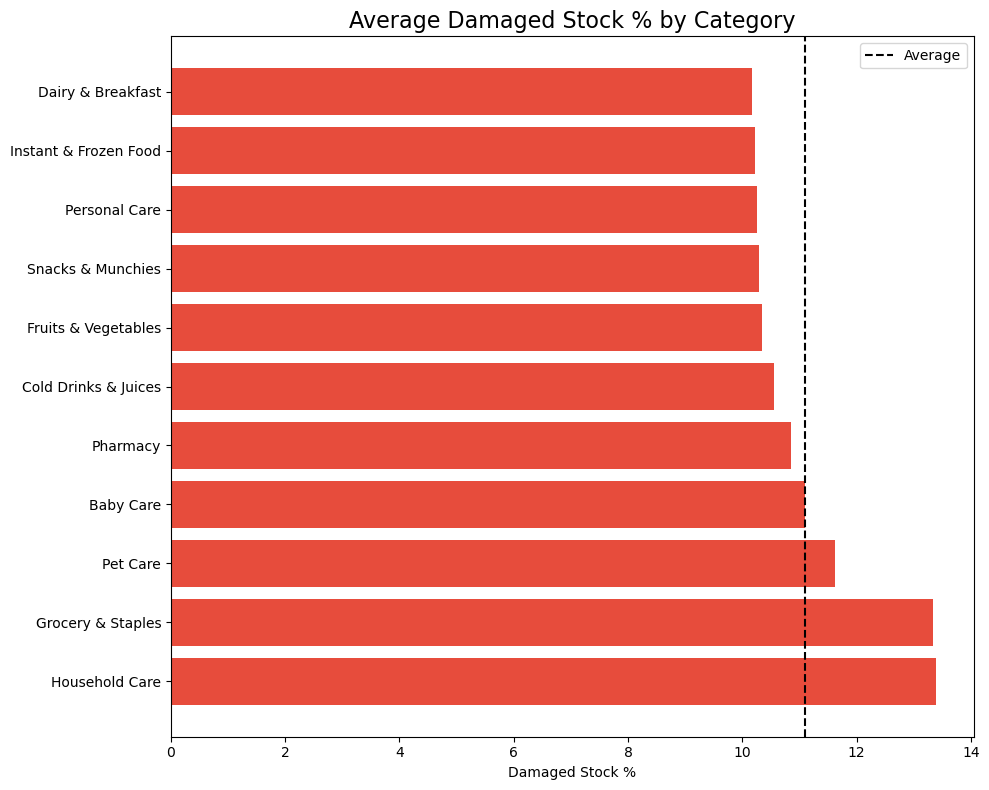

In [26]:
# Merge inventory with products
inv_merged = inventory.merge(products, on='product_id')

# Damage by category
damage_by_category = inv_merged.groupby('category')['Damaged Stock %'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,8))
plt.barh(damage_by_category.index,
         damage_by_category.values,
         color='#e74c3c')
plt.title('Average Damaged Stock % by Category', fontsize=16)
plt.xlabel('Damaged Stock %')
plt.axvline(x=damage_by_category.mean(), 
            color='black', 
            linestyle='--', 
            label='Average')
plt.legend()
plt.tight_layout()
plt.show()

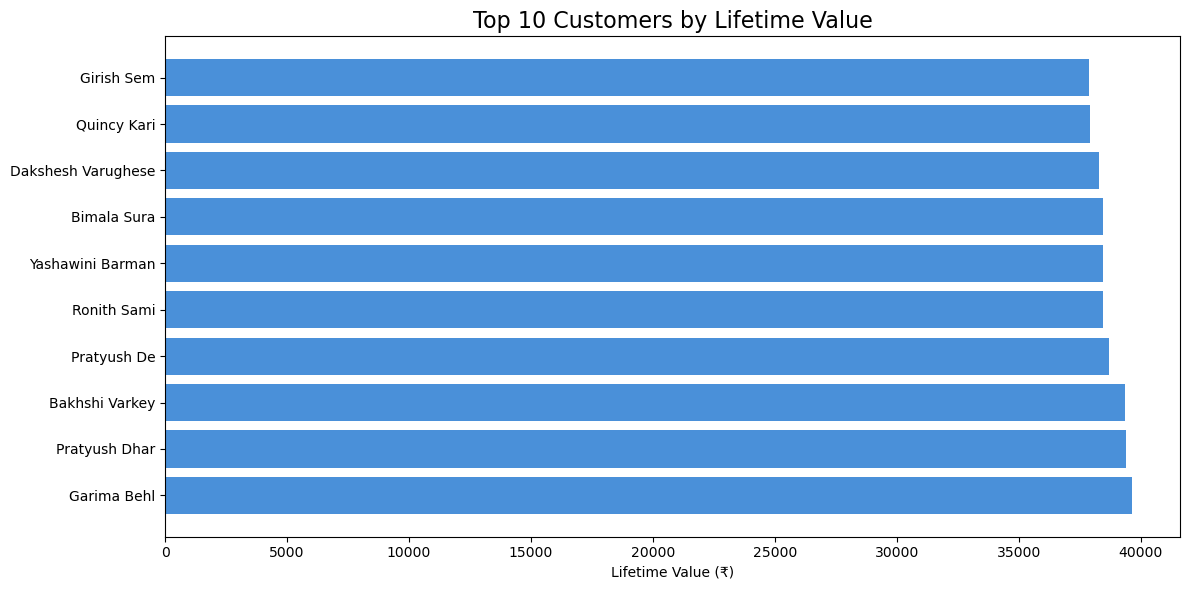

           customer_name customer_segment           area  lifetime_value
2488         Garima Behl              New  Muzaffarnagar         39634.4
2001       Pratyush Dhar         Inactive    Farrukhabad         39389.0
385       Bakhshi Varkey          Premium           Guna         39373.0
205          Pratyush De          Regular           Orai         38716.8
980          Ronith Sami              New      Singrauli         38472.8
1989    Yashawini Barman          Premium     Ramagundam         38467.8
673          Bimala Sura              New       Bathinda         38454.2
2346  Dakshesh Varughese          Regular     Pallavaram         38283.6
1870         Quincy Kari         Inactive     Saharanpur         37925.4
1349          Girish Sem         Inactive       Dehradun         37876.6


In [28]:
# Calculate Customer Lifetime Value
customers['lifetime_value'] = customers['total_orders'] * customers['avg_order_value']

# Top 10 customers
top_customers = customers.nlargest(10, 'lifetime_value')[['customer_name', 'customer_segment', 'area', 'lifetime_value']]

# Plot
plt.figure(figsize=(12,6))
plt.barh(top_customers['customer_name'],
         top_customers['lifetime_value'],
         color='#4a90d9')
plt.title('Top 10 Customers by Lifetime Value', fontsize=16)
plt.xlabel('Lifetime Value (₹)')
plt.tight_layout()
plt.show()

print(top_customers)

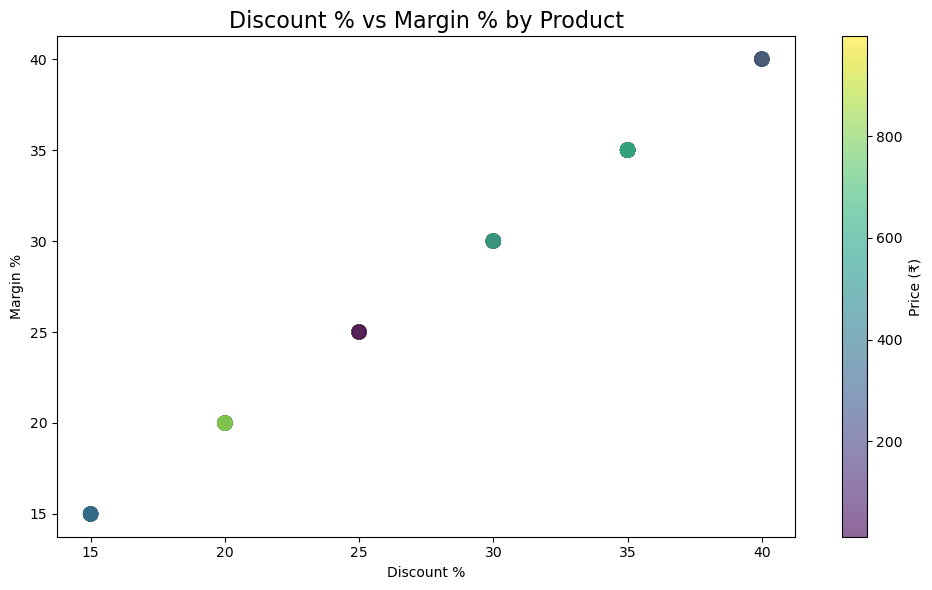

In [30]:
# Plot discount vs margin by category
plt.figure(figsize=(10,6))
scatter = plt.scatter(products['Discount %'],
           products['margin_percentage'],
           c=products['price'],
           cmap='viridis',
           alpha=0.6,
           s=100)
plt.colorbar(scatter, label='Price (₹)')
plt.title('Discount % vs Margin % by Product', fontsize=16)
plt.xlabel('Discount %')
plt.ylabel('Margin %')
plt.tight_layout()
plt.show()

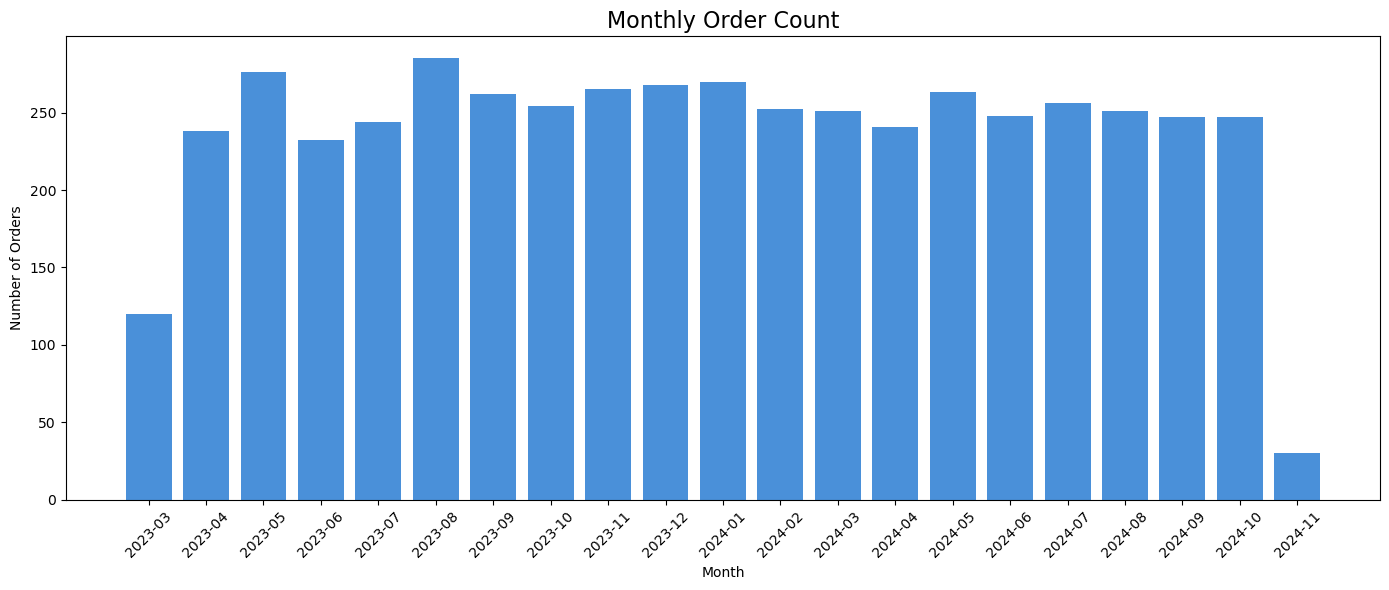

In [31]:
# Monthly order count
monthly_orders = orders.groupby('order_month')['order_id'].count().reset_index()
monthly_orders.columns = ['order_month', 'order_count']
monthly_orders['order_month'] = monthly_orders['order_month'].astype(str)

# Plot
plt.figure(figsize=(14,6))
plt.bar(monthly_orders['order_month'],
        monthly_orders['order_count'],
        color='#4a90d9')
plt.title('Monthly Order Count', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()